In [3]:
#import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [4]:
df = pd.read_csv('DATASET_EXAMEN_DE_INGRESO.csv')

In [5]:
#ANALISIS EXPLORATORIO
df.head()

,FOLIO,SEXO,CATEGORIA,TOTAL DE ACIERTOS,Ac_Esp,Ac_Mat,Ac_CNat,Ac_Geo,ac_His,Ac_FCEtica,Por_Esp,Por_Mat,Por_CNat,Por_Geo,Por_His,Por_FCÉtica,Por_tot
0,600000,H,URBANO,46,10,11,9,4,7,5,21.739130,23.913043,19.565217,8.695652,15.217391,10.869565,57.50
1,600001,H,URBANO,42,10,10,8,2,6,6,23.809524,23.809524,19.047619,4.761905,14.285714,14.285714,52.50
2,600002,M,URBANO,35,9,7,6,4,4,5,25.714286,20.000000,17.142857,11.428571,11.428571,14.285714,43.75
3,600003,M,URBANO,58,17,12,9,5,8,7,29.310345,20.689655,15.517241,8.620690,13.793103,12.068966,72.50
4,600004,H,URBANO,32,8,6,7,3,3,5,25.000000,18.750000,21.875000,9.375000,9.375000,15.625000,40.00


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54110 entries, 0 to 54109
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   FOLIO              54110 non-null  int64  
 1   SEXO               54110 non-null  object 
 2   CATEGORIA          54110 non-null  object 
 3   TOTAL DE ACIERTOS  54110 non-null  int64  
 4   Ac_Esp             54110 non-null  int64  
 5   Ac_Mat             54110 non-null  int64  
 6   Ac_CNat            54110 non-null  int64  
 7   Ac_Geo             54110 non-null  int64  
 8   ac_His             54110 non-null  int64  
 9   Ac_FCEtica         54110 non-null  int64  
 10  Por_Esp            54110 non-null  float64
 11  Por_Mat            54110 non-null  float64
 12  Por_CNat           54110 non-null  float64
 13  Por_Geo            54110 non-null  float64
 14  Por_His            54110 non-null  float64
 15  Por_FCÉtica        54110 non-null  float64
 16  Por_tot            541

In [7]:
df.describe()

,FOLIO,TOTAL DE ACIERTOS,Ac_Esp,Ac_Mat,Ac_CNat,Ac_Geo,ac_His,Ac_FCEtica,Por_Esp,Por_Mat,Por_CNat,Por_Geo,Por_His,Por_FCÉtica,Por_tot
count,54110.000000,54110.000000,54110.000000,54110.000000,54110.000000,54110.000000,54110.000000,54110.000000,54110.000000,54110.000000,54110.000000,54110.000000,54110.000000,54110.000000,54110.000000
mean,628078.083589,38.967418,10.410054,9.069211,5.731972,4.672648,4.225448,4.858085,26.716047,23.662633,14.622682,11.813301,10.759530,12.425808,48.709273
std,16336.954290,13.280129,4.036229,3.357730,2.416392,2.226475,2.177817,2.174523,6.021703,5.945517,4.353261,4.305155,4.369235,4.436894,16.600161
min,600000.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.250000
25%,613935.250000,28.000000,7.000000,7.000000,4.000000,3.000000,3.000000,3.000000,23.255814,20.000000,12.244898,9.375000,8.000000,10.000000,35.000000
50%,628081.500000,38.000000,10.000000,9.000000,6.000000,5.000000,4.000000,5.000000,26.666667,23.255814,14.754098,12.000000,10.714286,12.500000,47.500000
75%,642134.750000,49.000000,13.000000,11.000000,8.000000,6.000000,6.000000,6.000000,30.000000,26.923077,17.142857,14.285714,13.432836,15.000000,61.250000
max,700050.000000,80.000000,20.000000,20.000000,10.000000,10.000000,10.000000,10.000000,100.000000,66.666667,50.000000,46.666667,100.000000,46.153846,100.000000


In [8]:
print("Media genral: ", df['Por_tot'].mean())
print("Mediana:", df['Por_tot'].median())
print("Moda:", df['Por_tot'].mode()[0])
print("Desviacion estandar:", df['Por_tot'].std())

Media genral:  48.7092727776751
Mediana: 47.5
Moda: 33.75
Desviacion estandar: 16.600160816333275


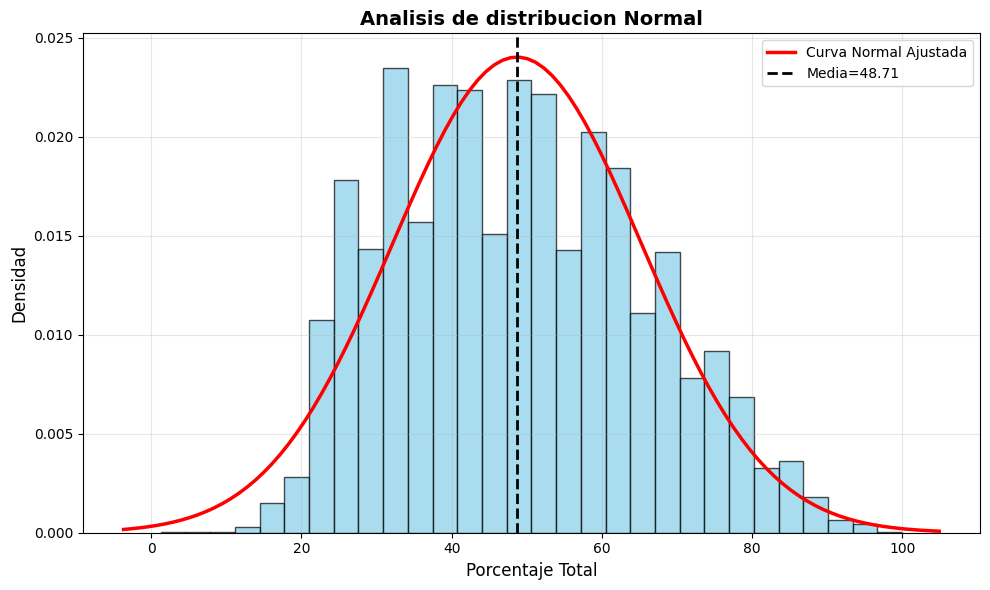

In [10]:
#visualizacion
x = df['Por_tot'].dropna().values
#histograma normalizado
plt.figure(figsize=(10, 6))
plt.hist(x, bins=30, color='skyblue', edgecolor='black', density=True, alpha=0.7)
#curva normal ajustada
mu, sigma = np.mean(x), np.std(x)
xmin, xmax = plt.xlim()
xvals = np.linspace(xmin, xmax, 100)
p = norm.pdf(xvals, mu, sigma)
plt.plot(xvals, p, 'r', linewidth=2.5, label='Curva Normal Ajustada')
plt.axvline(mu, color='black', linestyle='--', linewidth=2, label=f'Media={mu:.2f}')
plt.xlabel('Porcentaje Total', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.title('Analisis de distribucion Normal', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
#shapiro -wilk
# es de las pruebas mas usadas para muestras pequenas y grandes sobre normalidad
from scipy.stats import shapiro
stat,p = shapiro(x)
print("estadistico de shapiro:",stat)
print("p-valor:",p)
if p > 0.05:
    print(" No se rechazo la normalidad")
else:
    print("Se rechaza la normalidad")

estadistico de shapiro: 0.9811314414186301
p-valor: 6.509617299793066e-61
Se rechaza la normalidad


C:\Users\yasir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 54110.
  res = hypotest_fun_out(*samples, **kwds)


In [14]:
#komolgorov -smirnov
#comapara la distribucion de tus datos con uan normal teorica 
from scipy.stats import kstest
mu,sigma = np.mean(x), np.std(x)
stat,p = kstest(x, 'norm', args=(mu, sigma))
print("estadistico de kstest:",stat)
print("p-valor:",p)

if p>0.05:
    print("No se rechazo la normalidad")
else:
    print("Se rechazo la normalidad")

estadistico de kstest: 0.061110533773135856
p-valor: 4.1604737755402644e-176
Se rechazo la normalidad


##Observaciones y recomendaciones

SE OBSERVA QUE LOS DATOS NO SIGUEN UNA DISTRIBUCIÓN NORMAL Y ESTO SE COMPROBO CON LAS PRUEBAS DE SHAPIRO-WILK Y KOMOGOROV-SMIRNOV,
HAY TENDENCIAS MUY ALTAS ENTRE 20 Y 30 DE SCORE, LO CUAL ESTA MUY ALEJADO DE LA MEDIA.
CON RESPECTO AL CRITERIO MINIMO DE ACEPTACION LO TIENEN QUE VALORAR YA QUE LA MEDIA
DE LOS DATOS ES 48.71 QUE ES DONDE ESTA LA MAYORIA DE LOS DATOS
SI SE CONSIDERA EL 60 DE SCORE DEJARAS A MUCHOS FUERA DE LA MUESTRA Y DE CURSAR LA UNIVERSIDAD